# Embedding Extraction: Comparing Genomic Foundation Models

**Day 1 Afternoon - Session 1**

**Author:** Ikram Ullah, KAUST Bioinformatics Platform

---

## Overview

In this notebook, we'll extract **embeddings** from real genomic sequences using two different foundation models:

1. **HyenaDNA** - A state-space model for long DNA sequences
2. **Nucleotide Transformer** - A transformer-based model trained on reference genomes

We'll compare how these models represent the same sequences and visualize the learned representations.

---

## Learning Objectives

1. Extract embeddings from DNA sequences using pre-trained models
2. Apply **mean pooling** to get fixed-size representations
3. Visualize embeddings using **UMAP** and **t-SNE**
4. Compare how different models separate biological classes

---

## Biological Context

We'll work with two transcript biotypes from GENCODE:

| Biotype | Description |
|---------|-------------|
| **Protein-coding** | Templates for proteins; preserve reading frames, codon structure |
| **lncRNA** | Long non-coding RNAs; regulatory roles, different sequence patterns |

**Key question**: Can the models separate these biotypes *without* being told which is which?

If yes, it means the model has learned meaningful "DNA grammar" from pre-training.

---

## Setup

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from Bio import SeqIO
import umap
from sklearn.manifold import TSNE
import gzip

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Verify environment
print(f"Working directory: {os.getcwd()}")

Using device: cuda
Working directory: /home/ullahi/src/github/gfm-workshop/jupyter-notebooks/2.day1_after_lunch


## Part 1: Prepare Data

Extract protein-coding and lncRNA sequences from GENCODE.

In [2]:
# Paths
input_fasta = "../../data/gencode.v44.transcripts.fa.gz"
output_fasta = "../../output/gencode_protein_coding_lncRNA.fa"

# Ensure output directory exists
os.makedirs("../../output", exist_ok=True)

# Configuration
target_biotypes = {"protein_coding", "lncRNA"}
limits = {"protein_coding": 100, "lncRNA": 100}
counts = {biotype: 0 for biotype in target_biotypes}

# Extract sequences
print("Extracting sequences from GENCODE...")
with gzip.open(input_fasta, "rt") as handle, open(output_fasta, "w") as out_fh:
    for record in SeqIO.parse(handle, "fasta"):
        fields = record.description.split("|")
        if len(fields) >= 8:
            biotype = fields[7]
            if biotype in target_biotypes and counts[biotype] < limits[biotype]:
                SeqIO.write(record, out_fh, "fasta")
                counts[biotype] += 1
        
        if all(counts[b] >= limits[b] for b in target_biotypes):
            break

print(f"Extracted: {counts}")
print(f"Saved to: {output_fasta}")

Extracting sequences from GENCODE...
Extracted: {'lncRNA': 100, 'protein_coding': 100}
Saved to: ../../output/gencode_protein_coding_lncRNA.fa


In [3]:
# Load sequences and labels
records = list(SeqIO.parse(output_fasta, "fasta"))

labels = []
sequences = []

for record in records:
    fields = record.description.split("|")
    if len(fields) >= 8:
        biotype = fields[7]
        labels.append(biotype)
        # Convert to DNA (replace U with T)
        sequences.append(str(record.seq).upper().replace("U", "T"))

print(f"Loaded {len(sequences)} sequences")
print(f"Labels: {set(labels)}")
print(f"Sequence length range: {min(len(s) for s in sequences)} - {max(len(s) for s in sequences)} bp")

Loaded 200 sequences
Labels: {'lncRNA', 'protein_coding'}
Sequence length range: 168 - 8389 bp


## Part 2: HyenaDNA Embeddings

HyenaDNA uses a **state-space model** architecture that can handle very long sequences efficiently.

In [4]:
# Load HyenaDNA
hyena_name = "LongSafari/hyenadna-medium-160k-seqlen-hf"
print(f"Loading {hyena_name}...")

hyena_tokenizer = AutoTokenizer.from_pretrained(hyena_name, trust_remote_code=True)
hyena_model = AutoModel.from_pretrained(hyena_name, trust_remote_code=True)
hyena_model = hyena_model.to(device).eval()

print(f"HyenaDNA loaded successfully!")

Loading LongSafari/hyenadna-medium-160k-seqlen-hf...
HyenaDNA loaded successfully!


In [5]:
# Extract HyenaDNA embeddings
MAX_LEN = 300  # Truncate for speed

hyena_embeddings = []

print("Extracting HyenaDNA embeddings...")
with torch.no_grad():
    for i, seq in enumerate(sequences):
        seq_truncated = seq[:MAX_LEN]
        tokens = hyena_tokenizer(seq_truncated, return_tensors="pt").to(device)
        outputs = hyena_model(**tokens)
        
        # Mean pooling
        emb = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
        hyena_embeddings.append(emb[0])
        
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(sequences)}")

hyena_embeddings = np.stack(hyena_embeddings)
print(f"\nHyenaDNA embeddings shape: {hyena_embeddings.shape}")

Extracting HyenaDNA embeddings...
  Processed 50/200
  Processed 100/200
  Processed 150/200
  Processed 200/200

HyenaDNA embeddings shape: (200, 256)


## Part 3: Nucleotide Transformer Embeddings

Nucleotide Transformer uses a **transformer architecture** with k-mer tokenization.

In [6]:
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM

# Load Nucleotide Transformer
nt_name = "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species"
print(f"Loading {nt_name}...")

nt_tokenizer = AutoTokenizer.from_pretrained(nt_name, trust_remote_code=True)
nt_model = AutoModelForMaskedLM.from_pretrained(nt_name, trust_remote_code=True)
nt_model = nt_model.to(device).eval()

print(f"Nucleotide Transformer loaded successfully!")

Loading InstaDeepAI/nucleotide-transformer-v2-50m-multi-species...
Nucleotide Transformer loaded successfully!


In [7]:
# Extract NT embeddings
nt_embeddings = []

print("Extracting Nucleotide Transformer embeddings...")
with torch.no_grad():
    for i, seq in enumerate(sequences):
        seq_truncated = seq[:MAX_LEN]
        tokens = nt_tokenizer(seq_truncated, return_tensors="pt", padding=True, truncation=True).to(device)
        outputs = nt_model(**tokens, output_hidden_states=True)
        
        # Mean pooling with attention mask
        attention_mask = tokens["attention_mask"].unsqueeze(-1)
        masked_embeddings = outputs.hidden_states[-1] * attention_mask
        emb = masked_embeddings.sum(dim=1) / attention_mask.sum(dim=1)
        nt_embeddings.append(emb.cpu().numpy()[0])
        
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(sequences)}")

nt_embeddings = np.stack(nt_embeddings)
print(f"\nNT embeddings shape: {nt_embeddings.shape}")

Extracting Nucleotide Transformer embeddings...
  Processed 50/200
  Processed 100/200
  Processed 150/200
  Processed 200/200

NT embeddings shape: (200, 512)


## Part 4: Visualization

Let's visualize both embeddings side-by-side using UMAP and t-SNE.

### 4.1 UMAP Visualization

Running UMAP...


/home/ullahi/miniconda3/envs/gw-unified/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


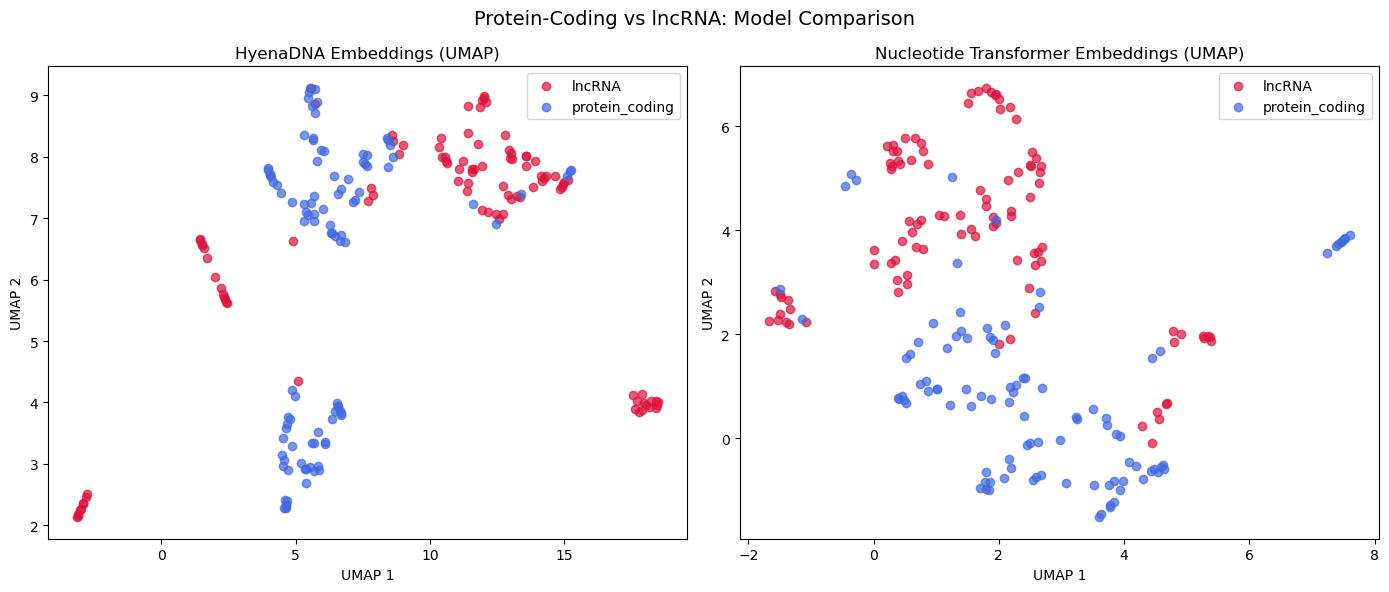

In [9]:
# UMAP for both models
print("Running UMAP...")
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, metric="cosine", random_state=47)

hyena_umap = reducer.fit_transform(hyena_embeddings)
nt_umap = reducer.fit_transform(nt_embeddings)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {"protein_coding": "royalblue", "lncRNA": "crimson"}

for ax, embeddings_2d, title in [
    (axes[0], hyena_umap, "HyenaDNA"),
    (axes[1], nt_umap, "Nucleotide Transformer")
]:
    for label in set(labels):
        idx = [i for i, l in enumerate(labels) if l == label]
        ax.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1],
                   label=label, alpha=0.7, color=colors.get(label, "gray"))
    ax.legend()
    ax.set_title(f"{title} Embeddings (UMAP)")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

plt.suptitle("Protein-Coding vs lncRNA: Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

### 4.2 t-SNE Visualization

Running t-SNE...


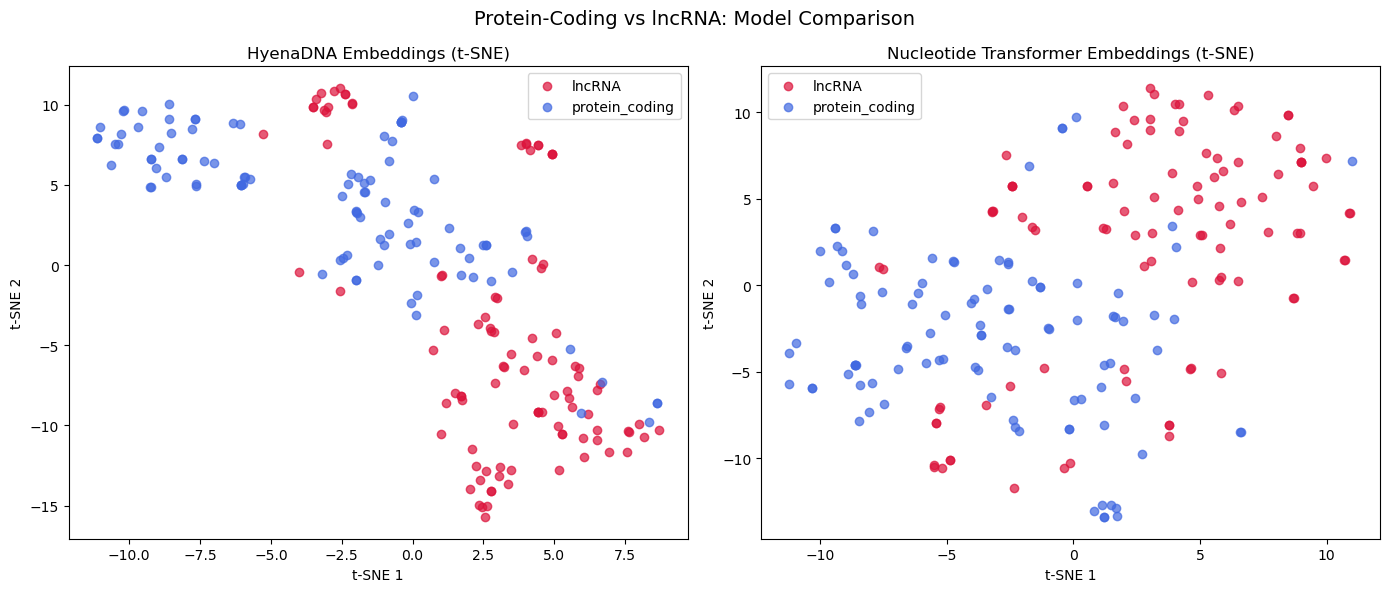

In [10]:
# t-SNE for both models
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=300, random_state=47)

hyena_tsne = tsne.fit_transform(hyena_embeddings)
nt_tsne = tsne.fit_transform(nt_embeddings)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, embeddings_2d, title in [
    (axes[0], hyena_tsne, "HyenaDNA"),
    (axes[1], nt_tsne, "Nucleotide Transformer")
]:
    for label in set(labels):
        idx = [i for i, l in enumerate(labels) if l == label]
        ax.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1],
                   label=label, alpha=0.7, color=colors.get(label, "gray"))
    ax.legend()
    ax.set_title(f"{title} Embeddings (t-SNE)")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle("Protein-Coding vs lncRNA: Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

---

## Discussion

### What patterns did the models learn?

If you see clear separation between protein-coding and lncRNA clusters, the models have learned to distinguish:

- **Codon periodicity** (3-nucleotide patterns in coding sequences)
- **ORF length distributions**  An ORF is a stretch of sequence that:
  - starts at a start codon (usually ATG, sometimes alternative starts)
  - continues in-frame with no stop codon
  - ends at a stop codon (TAA / TAG / TGA)

- **k-mer frequencies** that differ between coding and non-coding
- **Regulatory motifs** (e.g., Kozak sequences near start codons - `(gcc)gccRccAUGG`)

### Which model performed better?

Compare the cluster separation between HyenaDNA and Nucleotide Transformer. Consider:
- How tight are the clusters?
- How much overlap exists between classes?
- Are there any outliers?

---

## Reflection Questions

1. **Why do these models separate biotypes without explicit labels?**

2. **How could you use these embeddings for downstream tasks?**
   - Classification
   - Clustering
   - Anomaly detection

3. **What limitations does this small-scale experiment have?**

---

## Summary

| Model | Architecture | Embedding Dim | Strength |
|-------|--------------|---------------|----------|
| HyenaDNA | State-space | 256 | Very long context, scalable to 100kb+ |
| Nucleotide Transformer | Transformer | 512 | Strong pretrained representations, good transfer |

Both models learn meaningful representations that capture biological signals.

**Next**: We'll explore the Hugging Face ecosystem for accessing models and APIs.